# 02 · Baseline Models — Persistence, Seasonal Naive, XGBoost

One-hour-ahead PM2.5 forecasting on the **identical leakage-safe chronological split** produced by `01_EDA.ipynb` (train 2010–12, validation 2013, test 2014).

| Model | Prediction for hour *t* |
|---|---|
| Persistence | PM2.5 at *t-1* |
| Seasonal Naive (24 h) | PM2.5 at *t-24* (strict version, kept for reference) |
| Seasonal Naive, level-adjusted | `max(y(t-24) + [y(t-1) - y(t-25)], 0)`: yesterday's value for this hour, shifted by how much the series has moved over the last 24 h. No fitted parameters |
| Seasonal Drift (fitted β) | `y(t-1) + β·[y(t-24) - y(t-25)]`, with β fitted by least squares on the **training** split only |
| XGBoost | gradient-boosted trees on the same features as the ANN, log1p target, early stopping on **validation** |

Metrics (MAE, RMSE, R²) are in µg/m³ on the **raw** scale, computed only on hours where PM2.5 was actually measured.

*Run `01_EDA.ipynb` first. Run `03_ANN_Model.ipynb` afterwards for the 4-model comparison.*

## 1. Setup and load the saved splits

In [20]:
import joblib
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

DATA_DIR, RES_DIR = 'data', 'results'
os.makedirs(RES_DIR, exist_ok=True)

meta  = json.load(open(f'{DATA_DIR}/meta.json'))
TARGET, num_cols, cat_cols = meta['target'], meta['numerical_cols'], meta['categorical_cols']

train = pd.read_csv(f'{DATA_DIR}/train.csv', parse_dates=['datetime'])
val   = pd.read_csv(f'{DATA_DIR}/val.csv',   parse_dates=['datetime'])
test  = pd.read_csv(f'{DATA_DIR}/test.csv',  parse_dates=['datetime'])

print({k: len(v) for k, v in dict(train=train, val=val, test=test).items()})
print('Train:', train.datetime.min(), '->', train.datetime.max())
print('Val:  ', val.datetime.min(),   '->', val.datetime.max())
print('Test: ', test.datetime.min(),  '->', test.datetime.max())

{'train': 26256, 'val': 8760, 'test': 8760}
Train: 2010-01-03 00:00:00 -> 2012-12-31 23:00:00
Val:   2013-01-01 00:00:00 -> 2013-12-31 23:00:00
Test:  2014-01-01 00:00:00 -> 2014-12-31 23:00:00


### Add the lag-25 value needed by the improved seasonal baselines

`y(t-25)` is not in the saved feature set. It is built from the concatenated hourly series, so it only ever looks backwards in time, including across split boundaries.

In [21]:
full = pd.concat([train, val, test], ignore_index=True)
assert (full['datetime'].diff().dropna() == pd.Timedelta(hours=1)).all(), 'series must be gap-free hourly'
full['pm25_lag25'] = full[TARGET].shift(25)                       # strictly past data
train['pm25_lag25'] = full['pm25_lag25'].iloc[:len(train)].values
val['pm25_lag25']   = full['pm25_lag25'].iloc[len(train):len(train) + len(val)].values
test['pm25_lag25']  = full['pm25_lag25'].iloc[len(train) + len(val):].values
assert np.allclose(val['pm25_lag25'].values[:5], full[TARGET].iloc[len(train) - 25:len(train) - 20].values)
print('NaN lag-25 -> val:', val['pm25_lag25'].isna().sum(), '| test:', test['pm25_lag25'].isna().sum())

NaN lag-25 -> val: 0 | test: 0


## 2. Evaluation helper

Only hours with an observed target are scored (`target_observed`). Training rows are filtered the same way, so the models never learn from forward-filled targets.

In [22]:
def metrics(y_true, y_pred):
    return {'MAE':  mean_absolute_error(y_true, y_pred),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'R2':   r2_score(y_true, y_pred)}

# scored subsets (target actually measured)
tr, va, te = (d[d['target_observed']].reset_index(drop=True) for d in (train, val, test))
print(f'Scored rows -> train {len(tr)}, val {len(va)}, test {len(te)}')

Scored rows -> train 24394, val 8678, test 8661


## 3. Persistence and Seasonal Naive

Both are parameter-free. `pm25_lag1` is PM2.5 at *t-1*; `pm25_lag24` is PM2.5 at *t-24* (same hour yesterday).

In [23]:
# Seasonal Drift: y(t-1) + beta * [y(t-24) - y(t-25)], beta by least squares on TRAIN only
m = tr['pm25_lag25'].notna()
dy_tr = (tr.loc[m, TARGET] - tr.loc[m, 'pm25_lag1']).values
ds_tr = (tr.loc[m, 'pm25_lag24'] - tr.loc[m, 'pm25_lag25']).values
beta = float((dy_tr * ds_tr).sum() / (ds_tr ** 2).sum())
print(f'Seasonal Drift beta (fit on train) = {beta:.4f}')

preds = {n: {} for n in ['Persistence', 'Seasonal Naive (24h)', 'Seasonal Naive (level-adj.)', 'Seasonal Drift (fitted)']}
for split_name, d in [('val', va), ('test', te)]:
    preds['Persistence'][split_name]                 = d['pm25_lag1'].values
    preds['Seasonal Naive (24h)'][split_name]        = d['pm25_lag24'].values
    preds['Seasonal Naive (level-adj.)'][split_name] = np.maximum(d['pm25_lag24'] + d['pm25_lag1'] - d['pm25_lag25'], 0).values
    preds['Seasonal Drift (fitted)'][split_name]     = np.maximum(d['pm25_lag1'] + beta * (d['pm25_lag24'] - d['pm25_lag25']), 0).values

for name in preds:
    print(name)
    for s, d in [('val', va), ('test', te)]:
        m = metrics(d[TARGET].values, preds[name][s])
        print(f"  {s:4s}  MAE {m['MAE']:7.3f}   RMSE {m['RMSE']:7.3f}   R² {m['R2']:.4f}")

Seasonal Drift beta (fit on train) = 0.0287
Persistence
  val   MAE  13.208   RMSE  24.863   R² 0.9357
  test  MAE  11.959   RMSE  22.136   R² 0.9440
Seasonal Naive (24h)
  val   MAE  75.938   RMSE 109.972   R² -0.2576
  test  MAE  67.671   RMSE  99.502   R² -0.1319
Seasonal Naive (level-adj.)
  val   MAE  19.240   RMSE  32.716   R² 0.8887
  test  MAE  16.993   RMSE  28.361   R² 0.9080
Seasonal Drift (fitted)
  val   MAE  13.224   RMSE  24.874   R² 0.9357
  test  MAE  11.955   RMSE  22.122   R² 0.9441


## 4. XGBoost

Same input features as the ANN. The preprocessor is **fit on the training split only**. Trees do not need scaling, but using the same pipeline keeps the inputs identical across models. The target is `log1p(PM2.5)`, as in the ANN. Early stopping watches the **validation** year, never the test year.

In [24]:
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat_cols),
])
X_tr = preprocessor.fit_transform(tr)      # fit on TRAIN only
X_va = preprocessor.transform(va)
X_te = preprocessor.transform(te)
y_tr, y_va = np.log1p(tr[TARGET].values), np.log1p(va[TARGET].values)
print('Feature matrix shapes:', X_tr.shape, X_va.shape, X_te.shape)

Feature matrix shapes: (24394, 33) (8678, 33) (8661, 33)


In [25]:
xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    objective='reg:squarederror',
    eval_metric='rmse',
    early_stopping_rounds=100,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_va, y_va)], verbose=200)
print('Best iteration:', xgb.best_iteration)

def xgb_predict(X):
    return np.maximum(np.expm1(xgb.predict(X)), 0)

preds['XGBoost'] = {'val': xgb_predict(X_va), 'test': xgb_predict(X_te)}

[0]	validation_0-rmse:0.96987	validation_1-rmse:0.97569
[200]	validation_0-rmse:0.23360	validation_1-rmse:0.25605
[400]	validation_0-rmse:0.21725	validation_1-rmse:0.25516
[547]	validation_0-rmse:0.20765	validation_1-rmse:0.25525
Best iteration: 447


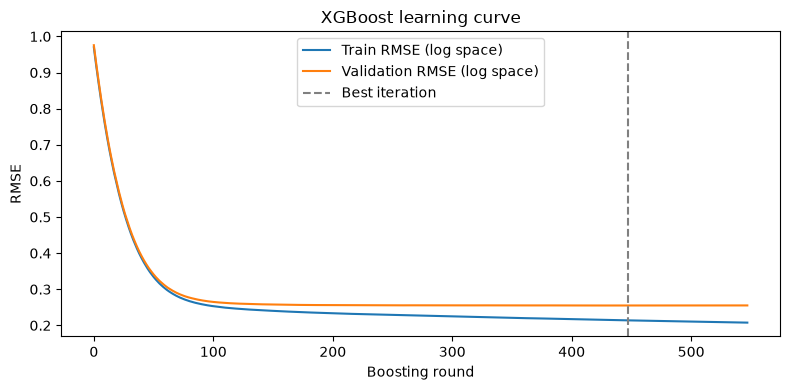

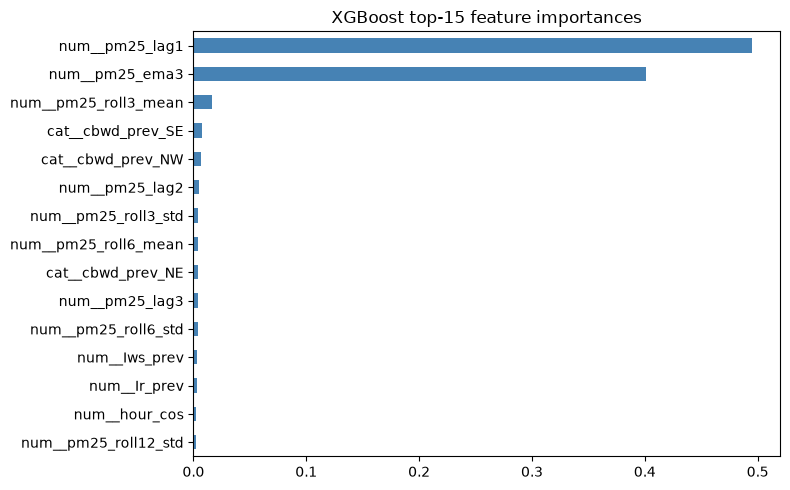

In [26]:
hist = xgb.evals_result()
plt.figure(figsize=(8, 4))
plt.plot(hist['validation_0']['rmse'], label='Train RMSE (log space)')
plt.plot(hist['validation_1']['rmse'], label='Validation RMSE (log space)')
plt.axvline(xgb.best_iteration, color='gray', ls='--', label='Best iteration')
plt.xlabel('Boosting round'); plt.ylabel('RMSE'); plt.title('XGBoost learning curve'); plt.legend()
plt.tight_layout(); plt.show()

imp = pd.Series(xgb.feature_importances_, index=preprocessor.get_feature_names_out()).sort_values(ascending=False)
imp.head(15).iloc[::-1].plot(kind='barh', figsize=(8, 5), color='steelblue', title='XGBoost top-15 feature importances')
plt.tight_layout(); plt.show()

## 5. Results — baselines

In [27]:
rows = []
for name in ['Persistence', 'Seasonal Naive (24h)', 'Seasonal Naive (level-adj.)', 'Seasonal Drift (fitted)', 'XGBoost']:
    for split_name, d in [('val', va), ('test', te)]:
        rows.append({'Model': name, 'Split': split_name, **metrics(d[TARGET].values, preds[name][split_name])})
res = pd.DataFrame(rows)

test_tbl = res[res.Split == 'test'].set_index('Model')[['MAE', 'RMSE', 'R2']].round(4)
print('TEST (2014) — hold-out year')
display(test_tbl)
print('VALIDATION (2013)')
display(res[res.Split == 'val'].set_index('Model')[['MAE', 'RMSE', 'R2']].round(4))

pers_rmse = test_tbl.loc['Persistence', 'RMSE']
for name in ['Seasonal Naive (24h)', 'Seasonal Naive (level-adj.)', 'Seasonal Drift (fitted)', 'XGBoost']:
    print(f"{name:28s}: RMSE {100 * (pers_rmse - test_tbl.loc[name, 'RMSE']) / pers_rmse:+.1f}% vs Persistence")

TEST (2014) — hold-out year


,MAE,RMSE,R2
Model,,,
Persistence,11.9590,22.1365,0.9440
Seasonal Naive (24h),67.6714,99.5022,-0.1319
Seasonal Naive (level-adj.),16.9926,28.3615,0.9080
Seasonal Drift (fitted),11.9552,22.1218,0.9441
XGBoost,12.1311,23.1141,0.9389


VALIDATION (2013)


,MAE,RMSE,R2
Model,,,
Persistence,13.2077,24.8630,0.9357
Seasonal Naive (24h),75.9383,109.9724,-0.2576
Seasonal Naive (level-adj.),19.2405,32.7158,0.8887
Seasonal Drift (fitted),13.2245,24.8743,0.9357
XGBoost,13.5666,28.5779,0.9151


Seasonal Naive (24h)        : RMSE -349.5% vs Persistence
Seasonal Naive (level-adj.) : RMSE -28.1% vs Persistence
Seasonal Drift (fitted)     : RMSE +0.1% vs Persistence
XGBoost                     : RMSE -4.4% vs Persistence


## 6. Save predictions and metrics for the final comparison

In [28]:
out = pd.DataFrame({'datetime': te['datetime'], 'y_true': te[TARGET].values})
out['Persistence']          = preds['Persistence']['test']
out['Seasonal Naive (24h)'] = preds['Seasonal Naive (24h)']['test']
out['Seasonal Naive (level-adj.)'] = preds['Seasonal Naive (level-adj.)']['test']
out['Seasonal Drift (fitted)']     = preds['Seasonal Drift (fitted)']['test']
out['XGBoost']              = preds['XGBoost']['test']
out.to_csv(f'{RES_DIR}/test_predictions_baselines.csv', index=False)
preprocessor_path = f'{RES_DIR}/baseline_preprocessor.pkl'
joblib.dump(preprocessor, preprocessor_path)
res.to_csv(f'{RES_DIR}/metrics_baselines.csv', index=False)
xgb.save_model(f'{RES_DIR}/pm25_xgboost.json')
print('Saved results/ ->', sorted(os.listdir(RES_DIR)))

Saved results/ -> ['baseline_preprocessor.pkl', 'metrics_baselines.csv', 'pm25_xgboost.json', 'test_predictions_baselines.csv']
